# Complete Exploratory Data Analysis (EDA) and Predictive Modeling on Movies Dataset

This notebook demonstrates a complete end-to-end data analysis, starting from theoretical foundations and applying them through practical implementation.

## 1. Load Data

**Theory:** EDA is an approach to analyzing datasets to summarize their main characteristics, often with visual methods. A statistical model can be used or not, but primarily EDA is for seeing what the data can tell us beyond the formal modeling or hypothesis testing task.

**Practical Implementation:** We will load our dataset, understand its shape, columns, find missing values, and observe basic descriptive statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('movies_dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (999999, 17)


,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
0,1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
1,2,He however experience,Comedy,1988,14-02-1988,USA,1883810.10,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
3,4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.10,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS


In [29]:
# Basic Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               999999 non-null  int64  
 1   Title                 999999 non-null  str    
 2   Genre                 999999 non-null  str    
 3   ReleaseYear           999999 non-null  int64  
 4   ReleaseDate           999999 non-null  str    
 5   Country               999999 non-null  str    
 6   BudgetUSD             999999 non-null  float64
 7   US_BoxOfficeUSD       999999 non-null  float64
 8   Global_BoxOfficeUSD   999999 non-null  float64
 9   Opening_Day_SalesUSD  999999 non-null  float64
 10  One_Week_SalesUSD     999999 non-null  float64
 11  IMDbRating            999999 non-null  float64
 12  RottenTomatoesScore   999999 non-null  int64  
 13  NumVotesIMDb          999999 non-null  int64  
 14  NumVotesRT            999999 non-null  int64  
 15  Director   

In [30]:
# Descriptive Statistics
df.describe()

,MovieID,ReleaseYear,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,999999.000000,999999.000000,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,9.999990e+05,999999.000000,999999.000000,999999.000000,999999.000000
mean,500000.000000,1998.001220,9.802824e+06,1.496163e+07,2.720625e+07,2.992745e+06,7.483442e+06,6.494788,64.776426,9137.184011,2031.880340
std,288674.990257,19.260863,2.249421e+07,3.879403e+07,6.954294e+07,8.132438e+06,1.955337e+07,1.485606,17.592474,24922.362780,8433.380602
min,1.000000,1950.000000,1.000000e+05,4.002547e+04,1.000000e+05,4.050470e+03,1.650742e+04,1.000000,0.000000,100.000000,50.000000
25%,250000.500000,1984.000000,1.190511e+06,1.489805e+06,2.762370e+06,2.790262e+05,7.383145e+05,5.500000,53.000000,1083.000000,119.000000
50%,500000.000000,2001.000000,3.265790e+06,4.388876e+06,8.090223e+06,8.387221e+05,2.179436e+06,6.500000,65.000000,2983.000000,405.000000
75%,749999.500000,2014.000000,9.002791e+06,1.287606e+07,2.355245e+07,2.510360e+06,6.415143e+06,7.500000,77.000000,8192.000000,1360.000000
max,999999.000000,2025.000000,3.000000e+08,1.018198e+09,1.499497e+09,2.957511e+08,5.795551e+08,10.000000,100.000000,1000000.000000,500000.000000


In [31]:
# Missing Values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

## 2. Exploratory Data Analysis (EDA)

**Theory:** Visualizations help in finding patterns, detecting outliers, and understanding the distribution of data. 

**Practical Implementation:** We will visualize the distribution of budget and revenue, and explore categorical variables like 'Genre' and 'LeadActor', as well as understanding the correlation between features like 'NumVotesIMDb' and 'Global_BoxOfficeUSD'.

### 2.1 Univariate Analysis - Histograms, Count Plots



Examining individual variables to understand their distributions.

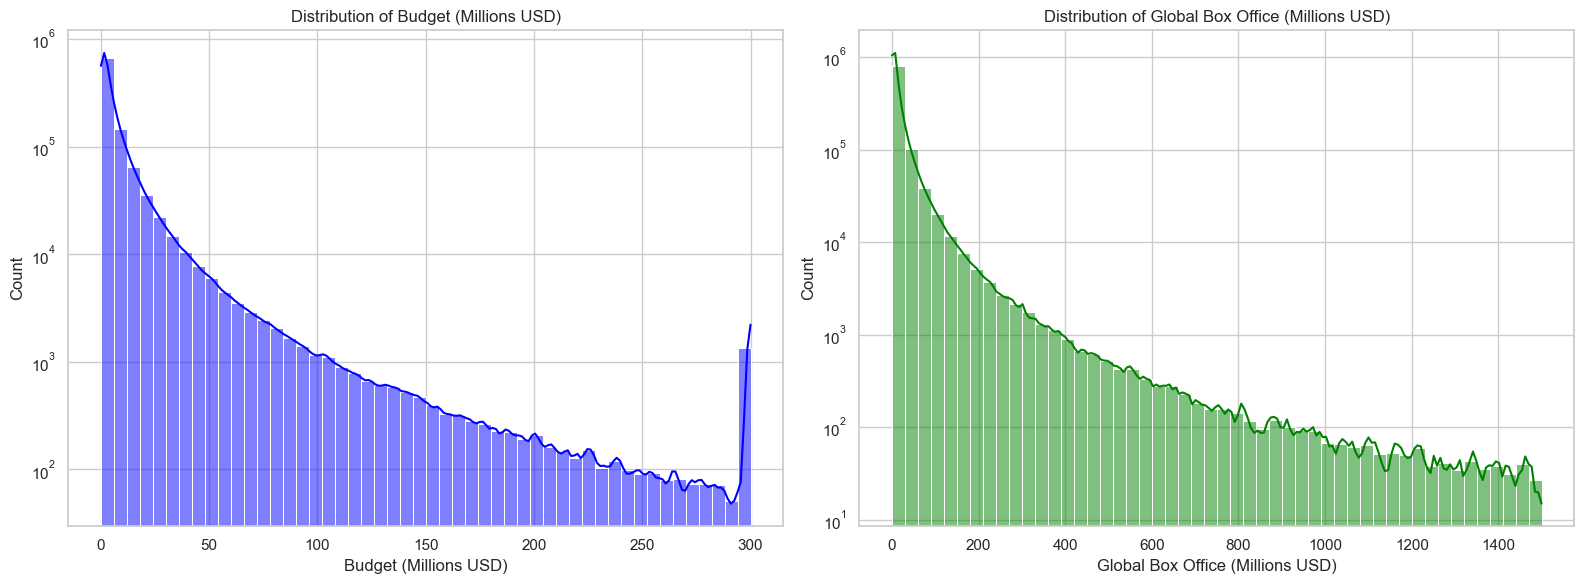

In [2]:
# Distribution of Budget and Global Box Office
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Helper function to format y-axis counts entirely in Thousands
def thousands_formatter(x, pos):
    return f'{x / 1000:g}'

# Convert to Millions for better plot readability
budget_m = df['BudgetUSD'].dropna() / 1e6
box_office_m = df['Global_BoxOfficeUSD'].dropna() / 1e6

sns.histplot(budget_m, bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Budget (Millions USD)')
axes[0].set_xlabel('Budget (Millions USD)')
axes[0].set_ylabel('Count (Thousands)')

sns.histplot(box_office_m, bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Global Box Office (Millions USD)')
axes[1].set_xlabel('Global Box Office (Millions USD)')
axes[1].set_ylabel('Count (Thousands)')

# Use log scale on y-axis to see the distribution of both small and extremely large values
axes[0].set_yscale('log')
axes[1].set_yscale('log')

# IMPORTANT: Set formatter AFTER setting the scale, otherwise log scale overrides it
axes[0].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
axes[1].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# Explicitly avoiding text annotations on bars to prevent overlapping and clutter
plt.tight_layout()
plt.show()

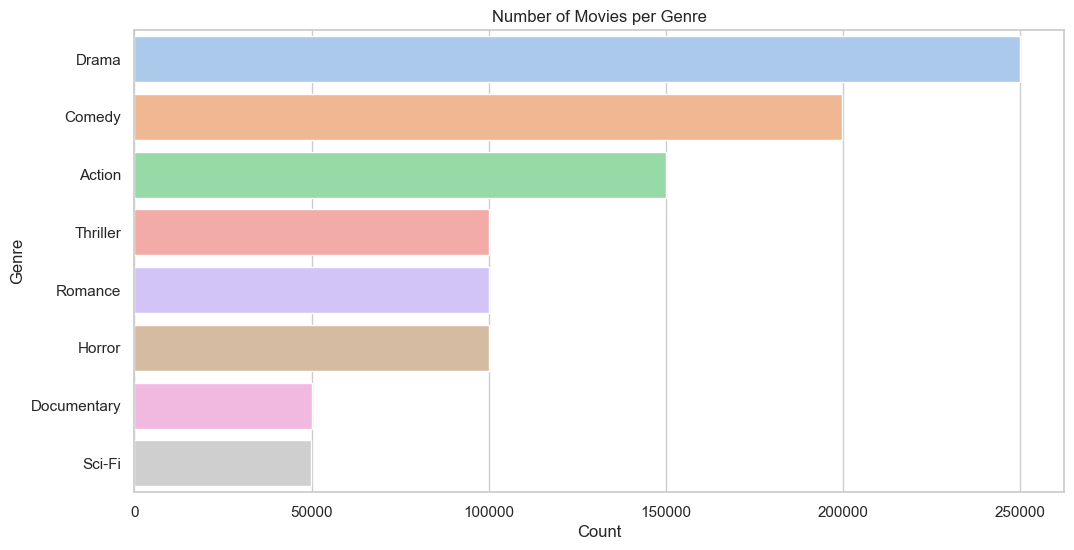

In [33]:
# Univariate Analysis: Count of Movies by Genre
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index, palette='pastel')
plt.title('Number of Movies per Genre')
plt.xlabel('Count')
plt.ylabel('Genre')
ax = plt.gca()
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.show()

### 2.2 Bivariate Analysis - Bar Plots, Scatter Plots, Box Plots



Examining relationships between two variables.

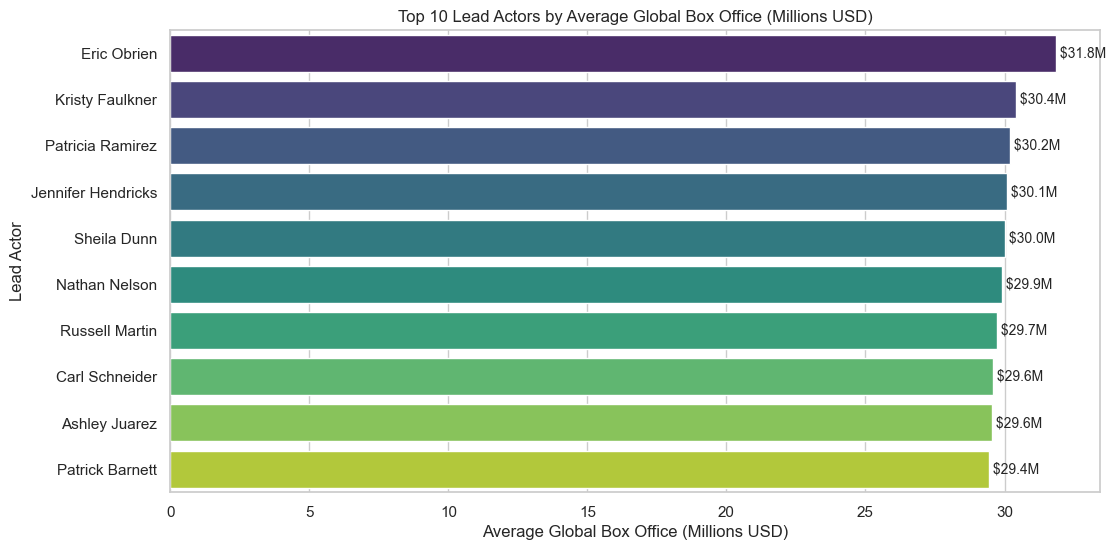

In [3]:
# Top 10 Lead Actors by Average Global Box Office
# We include 'LeadActor' to see if certain actors are associated with higher revenue as requested
# Converting to Millions USD for better visibility on the x-axis
top_actors_m = (df.groupby('LeadActor')['Global_BoxOfficeUSD'].mean() / 1e6).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_actors_m.values, y=top_actors_m.index, palette='viridis')
plt.title('Top 10 Lead Actors by Average Global Box Office (Millions USD)')
plt.xlabel('Average Global Box Office (Millions USD)')
plt.ylabel('Lead Actor')

ax = plt.gca()
for i, v in enumerate(top_actors_m.values):
    # Format as e.g. "$1,500M" or "$250.5M"
    ax.text(v, i, f" ${v:,.1f}M", va="center", fontsize=10)

plt.show()

Text(0, 0.5, 'Global Box Office (Millions USD)')

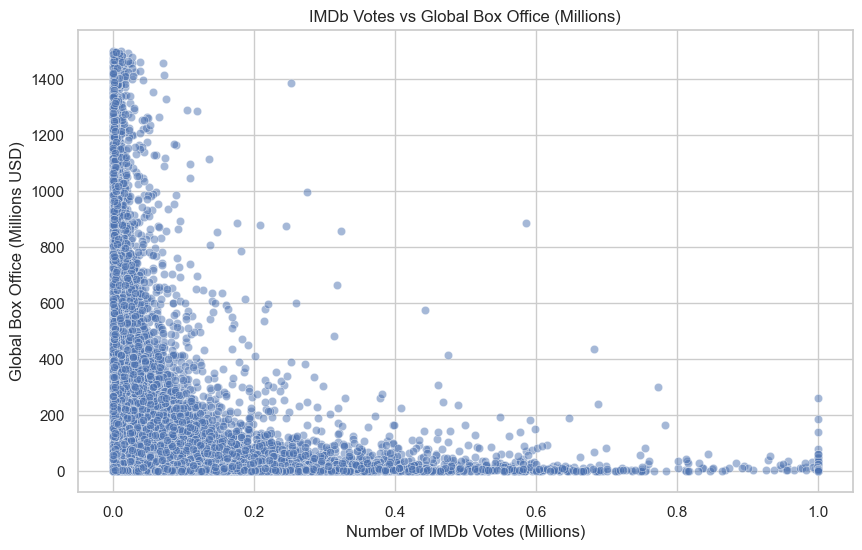

In [5]:
# Relationship between Number of Votes (IMDb) and Box Office
# We include 'NumVotesIMDb' as a measure of popularity corresponding to the 'numofvoting' requirement
plt.figure(figsize=(10, 6))

df_scatter = df.copy()
df_scatter['BoxOffice_Millions'] = df_scatter['Global_BoxOfficeUSD'] / 1e6
df_scatter['Votes_Millions'] = df_scatter['NumVotesIMDb'] / 1e6

sns.scatterplot(data=df_scatter, x='Votes_Millions', y='BoxOffice_Millions', alpha=0.5)
plt.title('IMDb Votes vs Global Box Office (Millions)')
plt.xlabel('Number of IMDb Votes (Millions)')
plt.ylabel('Global Box Office (Millions USD)')

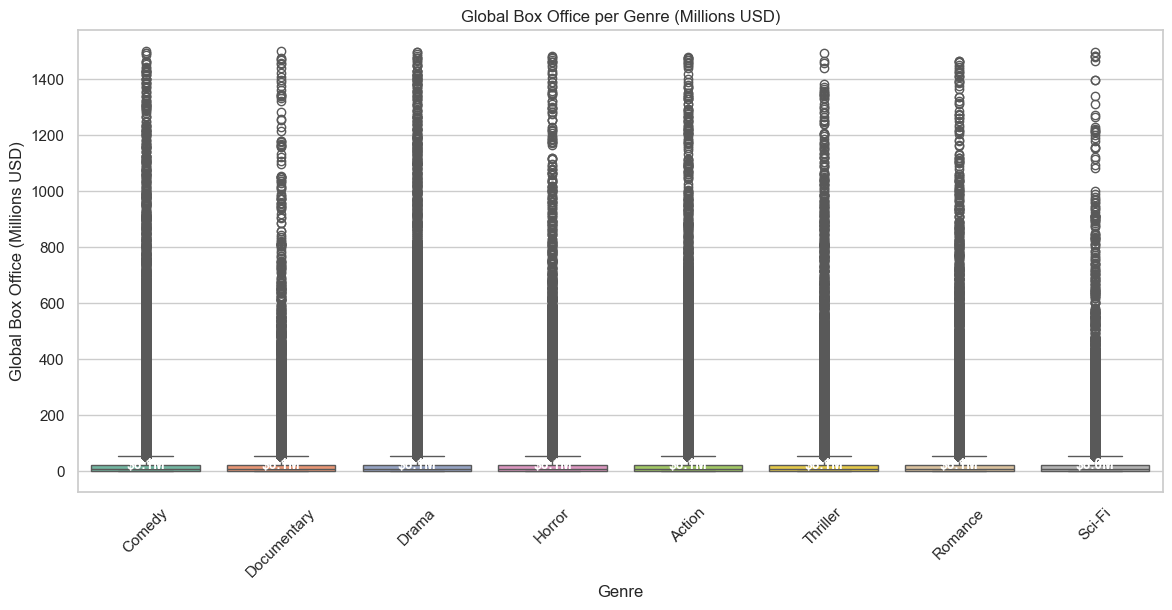

In [6]:
# Bivariate Analysis: Global Box Office distribution across Genres
plt.figure(figsize=(14, 6))

# Convert Box Office to Millions USD for readability
df_box = df.copy()
df_box['BoxOffice_Millions'] = df_box['Global_BoxOfficeUSD'] / 1e6

sns.boxplot(data=df_box, x='Genre', y='BoxOffice_Millions', palette='Set2')
plt.title('Global Box Office per Genre (Millions USD)')
plt.xlabel('Genre')
plt.ylabel('Global Box Office (Millions USD)')
plt.xticks(rotation=45)

ax = plt.gca()
medians = df_box.groupby(['Genre'])['BoxOffice_Millions'].median()
for tick, text in zip(ax.get_xticks(), ax.get_xticklabels()):
    genre_name = text.get_text()
    if genre_name in medians:
        # Format the text inside the boxplot (median)
        ax.text(tick, medians[genre_name], f"${medians[genre_name]:,.1f}M", 
                horizontalalignment='center', size='small', color='w', weight='semibold')
plt.show()

### 2.3 Multivariate Analysis - Correlation Matrix (Heatmap), Scatter Plots with Hue



Analyzing relationships between more than two variables.

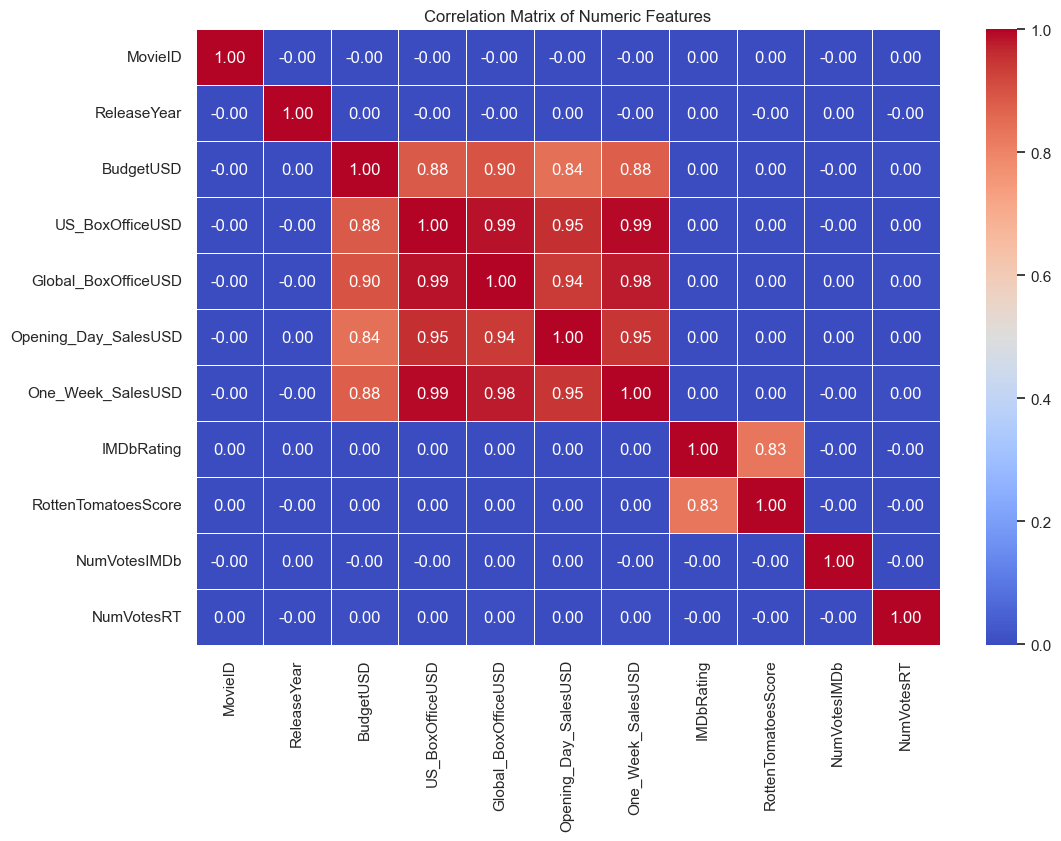

In [37]:
# Correlation Matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

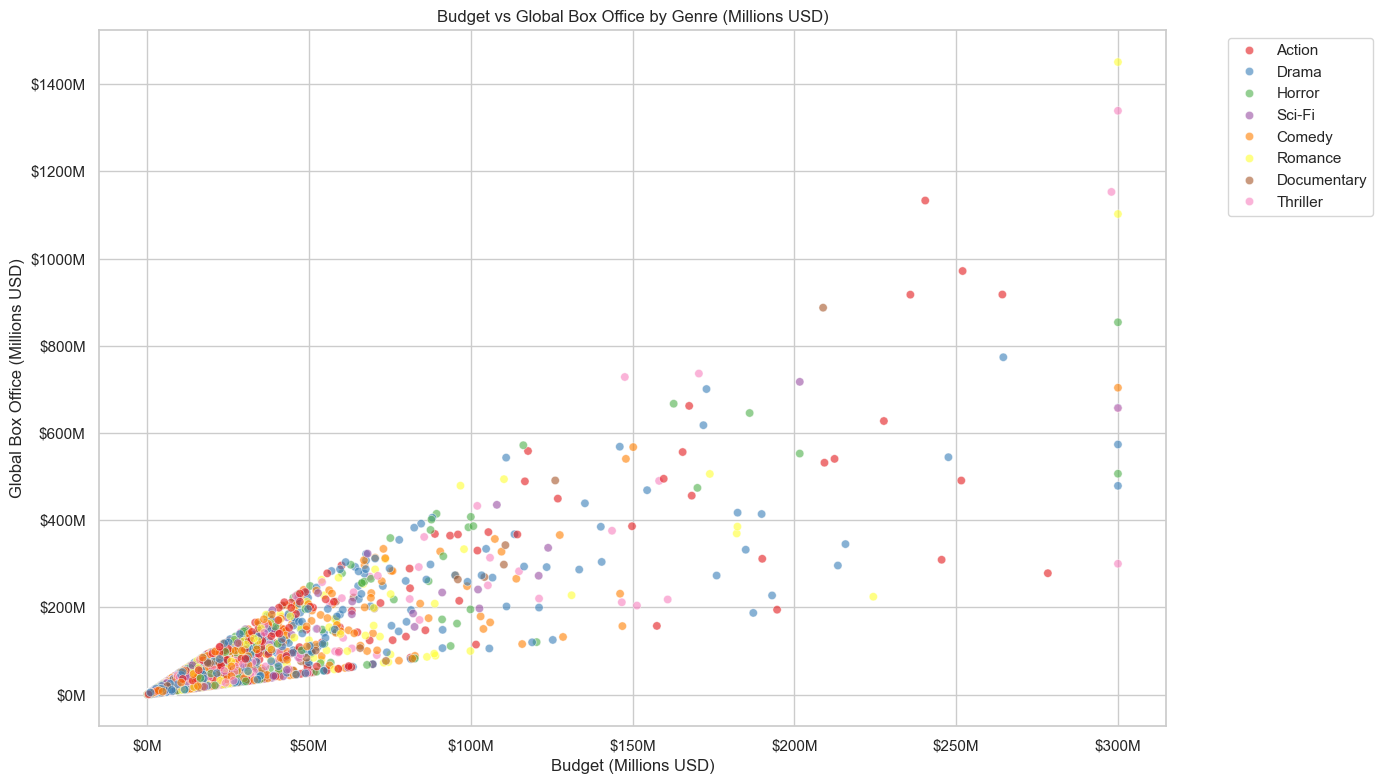

In [8]:
# Multivariate Analysis: Budget vs Global Box Office colored by Genre
# Using a sample to speed up plotting for the large dataset
plt.figure(figsize=(14, 8))

# Convert values to Millions USD
sample_df = df.sample(min(10000, len(df)), random_state=42).copy()
sample_df['Budget_Millions'] = sample_df['BudgetUSD'] / 1e6
sample_df['BoxOffice_Millions'] = sample_df['Global_BoxOfficeUSD'] / 1e6

sns.scatterplot(data=sample_df, x='Budget_Millions', y='BoxOffice_Millions', hue='Genre', alpha=0.6, palette='Set1')
plt.title('Budget vs Global Box Office by Genre (Millions USD)')
plt.xlabel('Budget (Millions USD)')
plt.ylabel('Global Box Office (Millions USD)')
from matplotlib.ticker import FuncFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:g}M'))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:g}M'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

## 3. Data Cleaning

Before jumping into outlier detection and regression models, it's essential to clean the data by handling missing values and duplicate rows.

In [39]:
# Data Cleaning
print('Initial dataset shape:', df.shape)

# 1. Drop Duplicates
df = df.drop_duplicates()
print('Shape after dropping duplicates:', df.shape)

# 2. Handle Missing Values
# Imputing numerical columns with median and categorical columns with mode
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after cleaning:', df.isnull().sum().sum())

Initial dataset shape: (999999, 17)
Shape after dropping duplicates: (999999, 17)
Missing values after cleaning: 0


## 4. Detect Outliers using Boxplots

Identifying outliers in the numerical features which might affect the machine learning models.

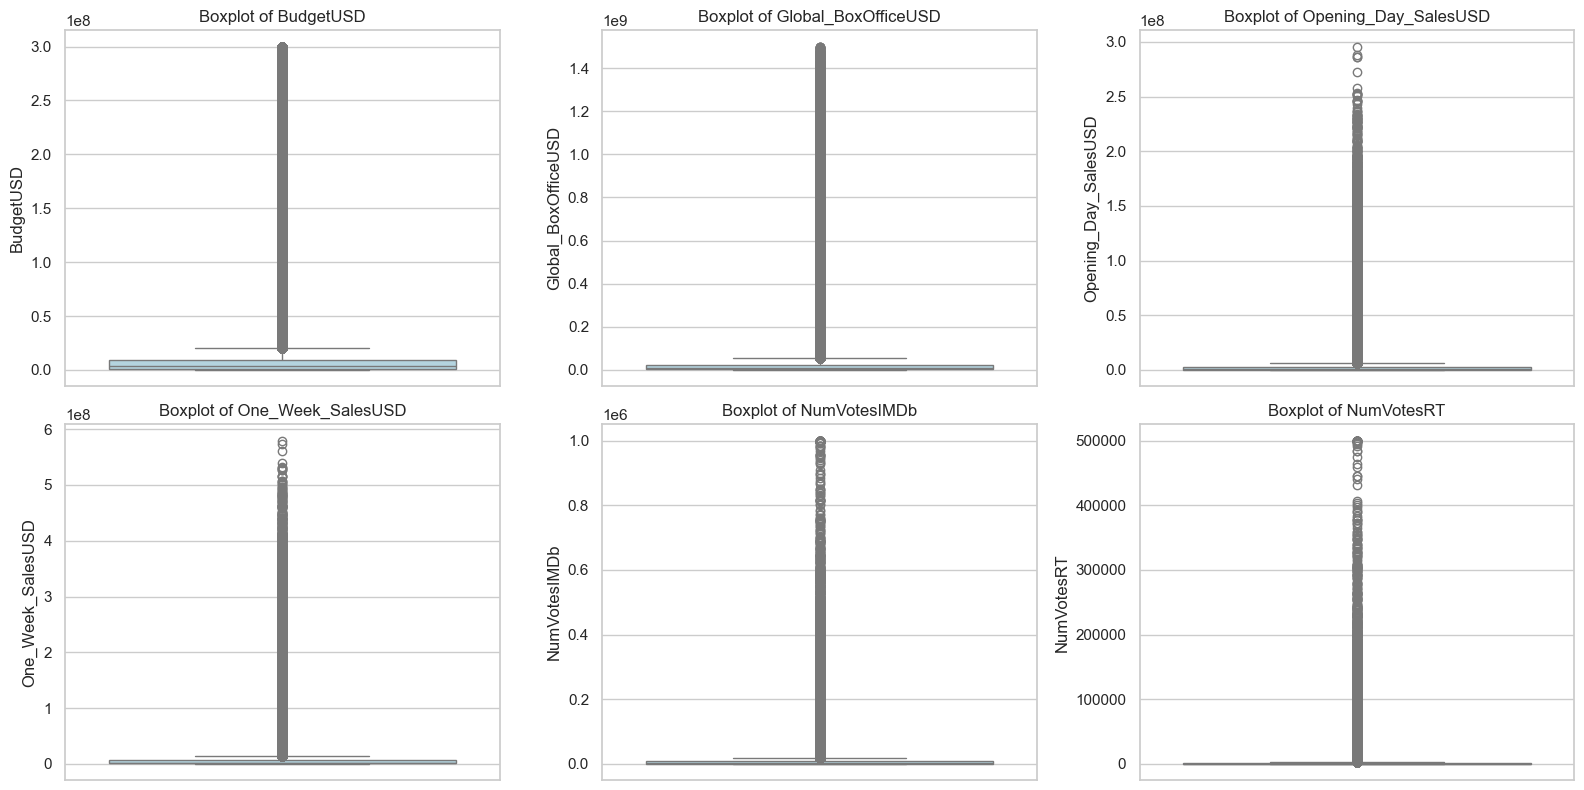

In [40]:
# Detect Outliers using Boxplots
plt.figure(figsize=(16, 12))
features_to_check = ['BudgetUSD', 'Global_BoxOfficeUSD', 'Opening_Day_SalesUSD', 'One_Week_SalesUSD', 'NumVotesIMDb', 'NumVotesRT']

for i, feature in enumerate(features_to_check, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[feature], color='lightblue')
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

## 5. Apply Regression Models

**Theory:** Regression analysis is a set of statistical processes for estimating the relationships between a dependent variable and one or more independent variables. 

**Practical Implementation:** We will predict `Global_BoxOfficeUSD` using continuous features like `BudgetUSD`, `Opening_Day_SalesUSD`, `IMDbRating`, and `NumVotesIMDb`. We train a Random Forest Regressor and a Linear Regressor.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop rows with missing values in critical columns
reg_features = ['BudgetUSD', 'Opening_Day_SalesUSD', 'IMDbRating', 'NumVotesIMDb']
target = 'Global_BoxOfficeUSD'

reg_df = df.dropna(subset=reg_features + [target])

X_reg = reg_df[reg_features]
y_reg = reg_df[target]

# Split the data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print(f"Training set size: {X_train_r.shape[0]}")
print(f"Testing set size: {X_test_r.shape[0]}")

Training set size: 799999
Testing set size: 200000


In [42]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

# Predict
y_pred_lr = lr_model.predict(X_test_r)

In [43]:
# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)

# Predict
y_pred_rf = rf_reg.predict(X_test_r)

## 6. Evaluate Models using Error Metrics (Regression)

**Theory:** 
- **MAE (Mean Absolute Error):** Average magnitude of errors.
- **RMSE (Root Mean Squared Error):** Standard deviation of the prediction errors. Penalizes large errors.
- **R² (Coefficient of Determination):** Proportion of the variance in the dependent variable that is predictable from the independent variables. Value closer to 1 means a very good fit.

**Practical Implementation:** We calculate these metrics to compare Linear Regression and Random Forest.

In [44]:
def evaluate_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²:   {r2:.4f}\n")

evaluate_regression(y_test_r, y_pred_lr, "Linear Regression")
evaluate_regression(y_test_r, y_pred_rf, "Random Forest Regression")

--- Linear Regression ---
MAE:  $6,373,922.20
RMSE: $19,684,999.04
R²:   0.9224

--- Random Forest Regression ---
MAE:  $5,778,316.64
RMSE: $18,463,720.74
R²:   0.9318



## 7. Classification

**Theory:** Classification is the problem of identifying to which of a set of categories a new observation belongs, on the basis of a training set of data containing observations whose category membership is known.

**Practical Implementation:** We will define a 'Blockbuster' as a movie whose `Global_BoxOfficeUSD` is at least 3 times its `BudgetUSD`. We will predict this binary class (1 for Blockbuster, 0 for Not).

In [45]:
# Create Classification Target: 'Is_Blockbuster' (Global Box Office > 3 * Budget)
clf_df = reg_df.copy()
# We define a hit/blockbuster as global box office > 3 times the budget
clf_df['Is_Blockbuster'] = (clf_df['Global_BoxOfficeUSD'] > 3 * clf_df['BudgetUSD']).astype(int)

# Class distribution
print(clf_df['Is_Blockbuster'].value_counts(normalize=True))

# Features for classification 
clf_features = ['BudgetUSD', 'Opening_Day_SalesUSD', 'IMDbRating', 'NumVotesIMDb']
X_clf = clf_df[clf_features]
y_clf = clf_df['Is_Blockbuster']

# Split Data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

Is_Blockbuster
0    0.555221
1    0.444779
Name: proportion, dtype: float64


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rfc = rf_clf.predict(X_test_c)

## 8. Evaluate Models using Error Metrics (Classification)

**Theory:**
- **Accuracy:** Ratio of correctly predicted observations to the total observations.
- **Precision:** Ratio of correctly predicted positive observations to the total predicted positive observations. Useful when false positives are costly.
- **Recall (Sensitivity):** Ratio of correctly predicted positive observations to the all observations in actual class. Useful when false negatives are costly.
- **F1 Score:** Weighted average of Precision and Recall. Useful when we have an uneven class distribution.

**Practical Implementation:** We evaluate the classifiers to see how well they predict 'Blockbusters'.

In [47]:
def evaluate_classification(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")

evaluate_classification(y_test_c, y_pred_log, "Logistic Regression")
evaluate_classification(y_test_c, y_pred_rfc, "Random Forest Classifier")

--- Logistic Regression ---
Accuracy:  0.8032
Precision: 0.8133
Recall:    0.7256
F1 Score:  0.7669

--- Random Forest Classifier ---
Accuracy:  0.8002
Precision: 0.7758
Recall:    0.7768
F1 Score:  0.7763



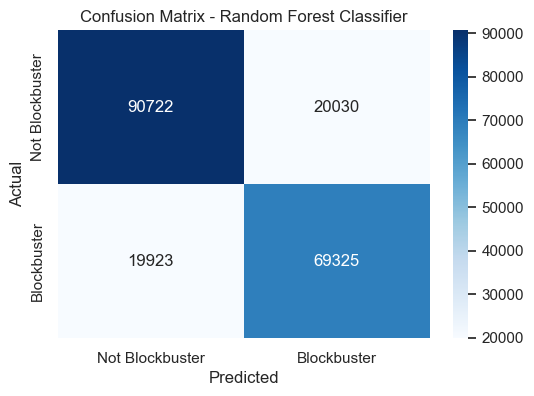

Classification Report - Random Forest Classifier:
                 precision    recall  f1-score   support

Not Blockbuster       0.82      0.82      0.82    110752
    Blockbuster       0.78      0.78      0.78     89248

       accuracy                           0.80    200000
      macro avg       0.80      0.80      0.80    200000
   weighted avg       0.80      0.80      0.80    200000



In [48]:
# Confusion Matrix for Random Forest Classifier
cm = confusion_matrix(y_test_c, y_pred_rfc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Blockbuster', 'Blockbuster'], yticklabels=['Not Blockbuster', 'Blockbuster'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("Classification Report - Random Forest Classifier:")
print(classification_report(y_test_c, y_pred_rfc, target_names=['Not Blockbuster', 'Blockbuster'], zero_division=0))

## Conclusion

This notebook connected the theory of Exploratory Data Analysis, Visualization, Regression, and Classification with practical implementation using Python and Scikit-Learn. We successfully investigated the `movies_dataset.csv`, engineered required features, incorporated actors' popularity representations like `LeadActor` and `NumVotesIMDb`, built models to forecast revenue and categorize blockbusters, all while critically evaluating these models using proper statistical error metrics.